In [1]:
import pandas as pd
import matplotlib as plt
from scipy.stats import zscore


#magic function to display graphs
%matplotlib inline


In [2]:
#import dataset
dataset = pd.read_csv(r'C:\Users\s843971\Desktop\california-housing-prices\housing.csv')

In [7]:
#view dataset
dataset.head(10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,lat_round,long_round,total_rooms_Z
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,38,-122,-0.804800
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,38,-122,2.045841
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,38,-122,-0.535733
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,38,-122,-0.624199
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,38,-122,-0.462393
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,38,-122,-0.786923
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,38,-122,-0.046187
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,38,-122,0.214629
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,38,-122,-0.037020
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY,38,-122,0.418606


In [4]:
dataset.shape

(20640, 10)

In [5]:

#first step - feature identification (continouos or catagorical)

#check for number of unique values for all features
dataset.housing_median_age.unique().shape
dataset.total_rooms.unique().shape
dataset.total_bedrooms.unique().shape
dataset.population.unique().shape
dataset.households.unique().shape
dataset.median_house_value.unique().shape
dataset.ocean_proximity.unique().shape

#for lat and long - round up the features and create new features lat_round and long_round

dataset['lat_round'] = dataset['latitude'].apply(lambda x: round(x))
dataset['long_round'] = dataset['longitude'].apply(lambda x: round(x))

dataset.lat_round.unique().shape
dataset.long_round.unique().shape


#based on above result -
#continuous - total_rooms, total_bedrooms, polupation, households, median_income, median_house_value(label)
#catagorical - latitude, longitude, housing_median_age, ocean_proximity

(11,)

In [32]:
#second step - univariate analysis - measure central tendencies and distribution of continuous varibles

#outlier treatment

#dataset.boxplot('total_rooms') 

# Calculate Z score for this feature 
dataset['total_rooms_Z'] = (dataset['total_rooms'] - dataset['total_rooms'].mean())/dataset['total_rooms'].std()
dataset['total_bedrooms_Z'] = (dataset['total_bedrooms'] - dataset['total_bedrooms'].mean())/dataset['total_bedrooms'].std()
dataset['population_Z'] = (dataset['population'] - dataset['population'].mean())/dataset['population'].std()
dataset['households_Z'] = (dataset['households'] - dataset['households'].mean())/dataset['households'].std()
dataset['median_income_Z'] = (dataset['median_income'] - dataset['median_income'].mean())/dataset['median_income'].std()

#Outliers are values which has Z score out of range -3 to +3. Capping these values at +3 and -3.
dataset['total_rooms_Z'] = (dataset['total_rooms'] - dataset['total_rooms'].mean())/dataset['total_rooms'].std()





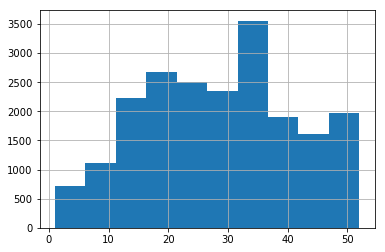

In [27]:
dataset['housing_median_age'].hist(bins=10)

In [ ]:
dataset.housing_median_age.unique()

In [30]:
dataset['lat_round'] = dataset['latitude'].apply(lambda x: round(x))
dataset['long_round'] = dataset['longitude'].apply(lambda x: round(x))

In [39]:
dataset.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [44]:
dataset.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,lat_round,long_round
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,35.667733,-119.479360
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,2.153597,2.017622
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,33.000000,-124.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,34.000000,-122.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,34.000000,-118.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,38.000000,-118.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,42.000000,-114.000000


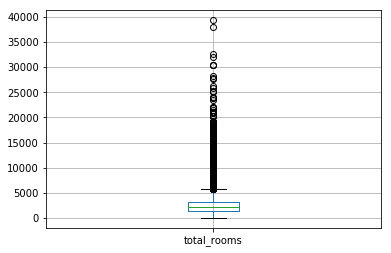

In [51]:
dataset.boxplot('total_rooms')

In [6]:
dataset['total_rooms_Z'] = (dataset['total_rooms'] - dataset['total_rooms'].mean())/dataset['total_rooms'].std()

In [31]:
dataset.loc[(dataset['total_rooms_Z'] > 3),['total_rooms','total_rooms_Z']].sort_values('total_rooms_Z')

,total_rooms,total_rooms_Z
6060,9197.0,3.007513
16559,9205.0,3.011180
1260,9217.0,3.016681
5963,9255.0,3.034099
3388,9259.0,3.035933
13519,9269.0,3.040516
20153,9280.0,3.045559
13940,9285.0,3.047850
11900,9286.0,3.048309
15540,9302.0,3.055643


In [14]:
dataset['total_rooms_Z'] = dataset['total_rooms_Z'].astype(float)